# 02 - Bayesian Optimization (Single Objective)

Core experiment: optimize Q45 using a Gaussian Process surrogate and Log Expected Improvement.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from botorch.fit import fit_gpytorch_mll
from botorch.models import SingleTaskGP
from botorch.models.transforms import Normalize, Standardize
from botorch.acquisition.analytic import LogExpectedImprovement
from botorch.optim import optimize_acqf
from gpytorch.mlls import ExactMarginalLogLikelihood

plt.style.use('seaborn-v0_8-whitegrid')
torch.set_default_dtype(torch.double)

In [3]:
import numpy as np
import pandas as pd

API_PCT = 30.0
TOTAL_EXCIPIENT_PCT = 100.0 - API_PCT

BOUNDS = {
    "hpmc": (0.0, 20.0),
    "mcc": (20.0, 60.0),
    "ccs": (1.0, 8.0),
    "mgst": (0.25, 2.0),
    "pvp": (0.0, 10.0),
}


def _physics_q45(hpmc, mcc, ccs, mgst, pvp):
    """
    Physics-informed synthetic dissolution model (% released at 45 min).

    Scientific assumptions encoded:
    - HPMC retards dissolution with nonlinear gel-layer penalty.
    - CCS improves dissolution with a saturable response.
    - MgSt reduces dissolution due to hydrophobic film formation.
    - MCC and PVP provide mild positive wetting/compactibility effects.
    - HPMC × CCS interaction reduces CCS effectiveness at high HPMC.
    """
    ccs_gain = 24.0 * (1.0 - np.exp(-ccs / 2.2))
    q45 = (
        48.0
        + 0.45 * mcc
        + 0.90 * pvp
        + ccs_gain
        - 1.05 * hpmc
        - 0.035 * (hpmc ** 2)
        - 7.2 * mgst
        - 0.16 * hpmc * ccs
    )
    return np.clip(q45, 0.0, 100.0)


def simulate_dissolution(df, noise_std=2.0, seed=0):
    """Simulate Q45 for one or many formulations."""
    rng = np.random.default_rng(seed)
    expected = _physics_q45(
        df["hpmc"].to_numpy(),
        df["mcc"].to_numpy(),
        df["ccs"].to_numpy(),
        df["mgst"].to_numpy(),
        df["pvp"].to_numpy(),
    )
    observed = expected + rng.normal(0.0, noise_std, size=len(df))
    return np.clip(observed, 0.0, 100.0)


def is_feasible(df):
    """Check formulation bounds and mass-balance constraints."""
    checks = []
    for name, (lo, hi) in BOUNDS.items():
        checks.append(df[name].between(lo, hi))
    sum_ok = np.isclose(df[["hpmc", "mcc", "ccs", "mgst", "pvp"]].sum(axis=1), TOTAL_EXCIPIENT_PCT, atol=1e-6)
    return np.logical_and.reduce(checks + [sum_ok])


def sample_feasible(n, seed=0):
    """Rejection sample feasible formulations under x5 = 70 - (x1+x2+x3+x4)."""
    rng = np.random.default_rng(seed)
    rows = []
    while len(rows) < n:
        hpmc = rng.uniform(*BOUNDS["hpmc"])
        mcc = rng.uniform(*BOUNDS["mcc"])
        ccs = rng.uniform(*BOUNDS["ccs"])
        mgst = rng.uniform(*BOUNDS["mgst"])
        pvp = TOTAL_EXCIPIENT_PCT - (hpmc + mcc + ccs + mgst)
        if BOUNDS["pvp"][0] <= pvp <= BOUNDS["pvp"][1]:
            rows.append((hpmc, mcc, ccs, mgst, pvp))
    return pd.DataFrame(rows, columns=["hpmc", "mcc", "ccs", "mgst", "pvp"])

In [4]:
TORCH_BOUNDS = torch.tensor([
    [BOUNDS["hpmc"][0], BOUNDS["mcc"][0], BOUNDS["ccs"][0], BOUNDS["mgst"][0]],
    [BOUNDS["hpmc"][1], BOUNDS["mcc"][1], BOUNDS["ccs"][1], BOUNDS["mgst"][1]],
], dtype=torch.double)


def augment_with_pvp(X4: torch.Tensor) -> torch.Tensor:
    pvp = TOTAL_EXCIPIENT_PCT - X4.sum(dim=-1, keepdim=True)
    return torch.cat([X4, pvp], dim=-1)


def feasible_mask(X4: torch.Tensor) -> torch.Tensor:
    pvp = TOTAL_EXCIPIENT_PCT - X4.sum(dim=-1)
    return (pvp >= BOUNDS["pvp"][0]) & (pvp <= BOUNDS["pvp"][1])


def simulate_q45_torch(X4: torch.Tensor, noise_std: float = 2.0, seed: int = 0) -> torch.Tensor:
    rng = np.random.default_rng(seed)
    X = augment_with_pvp(X4).detach().cpu().numpy()
    df = pd.DataFrame(X, columns=["hpmc", "mcc", "ccs", "mgst", "pvp"])
    y = simulate_dissolution(df, noise_std=noise_std, seed=seed)
    return torch.tensor(y, dtype=torch.double).unsqueeze(-1)


def sample_sobol_feasible(n: int, seed: int = 0) -> torch.Tensor:
    sobol = torch.quasirandom.SobolEngine(dimension=4, scramble=True, seed=seed)
    out = []
    while len(out) < n:
        X = sobol.draw(4 * n)
        X = TORCH_BOUNDS[0] + (TORCH_BOUNDS[1] - TORCH_BOUNDS[0]) * X
        X = X[feasible_mask(X)]
        out.extend([x for x in X])
    return torch.stack(out[:n])

## BO loop implementation

In [5]:
class FormulationBOLoop:
    def __init__(self, n_init: int = 10, noise_std: float = 2.0, seed: int = 0):
        self.n_init = n_init
        self.noise_std = noise_std
        self.seed = seed
        self.iteration = 0
        self.X = None
        self.Y = None
        self.model = None

    def initialize(self):
        self.X = sample_sobol_feasible(self.n_init, seed=self.seed)
        self.Y = simulate_q45_torch(self.X, noise_std=self.noise_std, seed=self.seed)

    def fit_model(self):
        self.model = SingleTaskGP(
            self.X,
            self.Y,
            input_transform=Normalize(d=4),
            outcome_transform=Standardize(m=1),
        )
        mll = ExactMarginalLogLikelihood(self.model.likelihood, self.model)
        fit_gpytorch_mll(mll)

    def suggest_next(self):
        best_f = self.Y.max()
        acqf = LogExpectedImprovement(self.model, best_f=best_f)
        ineq = [
            (torch.tensor([0, 1, 2, 3]), torch.tensor([1.0, 1.0, 1.0, 1.0], dtype=torch.double), 60.0),
            (torch.tensor([0, 1, 2, 3]), torch.tensor([-1.0, -1.0, -1.0, -1.0], dtype=torch.double), -70.0),
        ]
        candidate, acq_value = optimize_acqf(
            acq_function=acqf,
            bounds=TORCH_BOUNDS,
            q=1,
            num_restarts=20,
            raw_samples=256,
            inequality_constraints=ineq,
            options={"batch_limit": 5, "maxiter": 200},
        )
        return candidate, acq_value.item()

    def step(self):
        self.fit_model()
        x_next, acq_val = self.suggest_next()
        y_next = simulate_q45_torch(x_next, noise_std=self.noise_std, seed=self.seed + 1000 + self.iteration)
        self.X = torch.cat([self.X, x_next], dim=0)
        self.Y = torch.cat([self.Y, y_next], dim=0)
        self.iteration += 1

        x_full = augment_with_pvp(x_next).squeeze(0).detach().cpu().numpy()
        return {
            "iteration": self.iteration,
            "hpmc": x_full[0],
            "mcc": x_full[1],
            "ccs": x_full[2],
            "mgst": x_full[3],
            "pvp": x_full[4],
            "q45_observed": float(y_next.item()),
            "acq_value": acq_val,
            "best_so_far": float(self.Y.max().item()),
        }

    def run(self, n_iter: int = 30):
        if self.X is None:
            self.initialize()
        history = []
        for _ in range(n_iter):
            history.append(self.step())
        return pd.DataFrame(history)

    def best_so_far(self):
        idx = int(torch.argmax(self.Y).item())
        x_full = augment_with_pvp(self.X[idx: idx + 1]).squeeze(0).detach().cpu().numpy()
        return {
            "hpmc": x_full[0],
            "mcc": x_full[1],
            "ccs": x_full[2],
            "mgst": x_full[3],
            "pvp": x_full[4],
            "q45": float(self.Y[idx].item()),
        }

## Run optimization (10 init + 30 BO steps)

In [6]:
bo = FormulationBOLoop(n_init=10, noise_std=2.0, seed=42)
bo.initialize()
history = bo.run(n_iter=30)
best = bo.best_so_far()

print("Best observed formulation:")
for k, v in best.items():
    print(f"  {k}: {v:.3f}" if isinstance(v, float) else f"  {k}: {v}")

Best observed formulation:
  hpmc: 0.000
  mcc: 51.653
  ccs: 8.000
  mgst: 0.347
  pvp: 10.000
  q45: 100.000


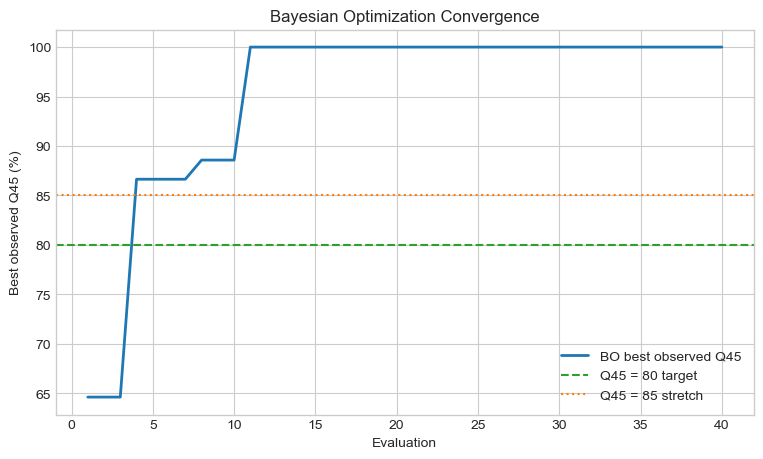

In [6]:
# Convergence plot
init_best = np.maximum.accumulate(bo.Y[:bo.n_init].detach().cpu().numpy().ravel())
full_best = np.maximum.accumulate(bo.Y.detach().cpu().numpy().ravel())

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, len(full_best) + 1), full_best, lw=2, label="BO best observed Q45")
ax.axhline(80, color="tab:green", ls="--", label="Q45 = 80 target")
ax.axhline(85, color="tab:orange", ls=":", label="Q45 = 85 stretch")
ax.set_xlabel("Evaluation")
ax.set_ylabel("Best observed Q45 (%)")
ax.set_title("Bayesian Optimization Convergence")
ax.legend()
plt.show()

## GP posterior slice (HPMC vs CCS)

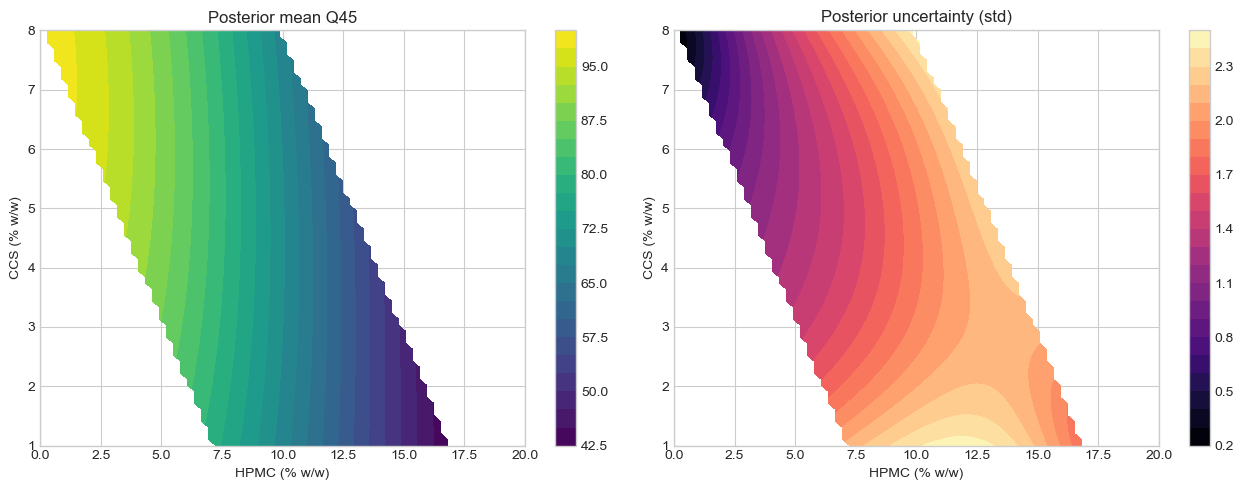

In [7]:
bo.fit_model()

best_idx = int(torch.argmax(bo.Y).item())
x_best = bo.X[best_idx].clone()

hpmc_grid = torch.linspace(*BOUNDS["hpmc"], 70, dtype=torch.double)
ccs_grid = torch.linspace(*BOUNDS["ccs"], 70, dtype=torch.double)
mean = np.full((len(ccs_grid), len(hpmc_grid)), np.nan)
std = np.full_like(mean, np.nan)

for i, ccs in enumerate(ccs_grid):
    for j, hpmc in enumerate(hpmc_grid):
        x = x_best.clone()
        x[0] = hpmc
        x[2] = ccs
        if feasible_mask(x.unsqueeze(0)):
            post = bo.model.posterior(x.unsqueeze(0))
            mean[i, j] = post.mean.item()
            std[i, j] = post.variance.sqrt().item()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cm1 = axes[0].contourf(hpmc_grid.numpy(), ccs_grid.numpy(), mean, levels=24, cmap="viridis")
axes[0].set_title("Posterior mean Q45")
axes[0].set_xlabel("HPMC (% w/w)")
axes[0].set_ylabel("CCS (% w/w)")
fig.colorbar(cm1, ax=axes[0])

cm2 = axes[1].contourf(hpmc_grid.numpy(), ccs_grid.numpy(), std, levels=24, cmap="magma")
axes[1].set_title("Posterior uncertainty (std)")
axes[1].set_xlabel("HPMC (% w/w)")
axes[1].set_ylabel("CCS (% w/w)")
fig.colorbar(cm2, ax=axes[1])
plt.tight_layout()
plt.show()

## Acquisition landscape snapshots (steps 5, 15, 30)

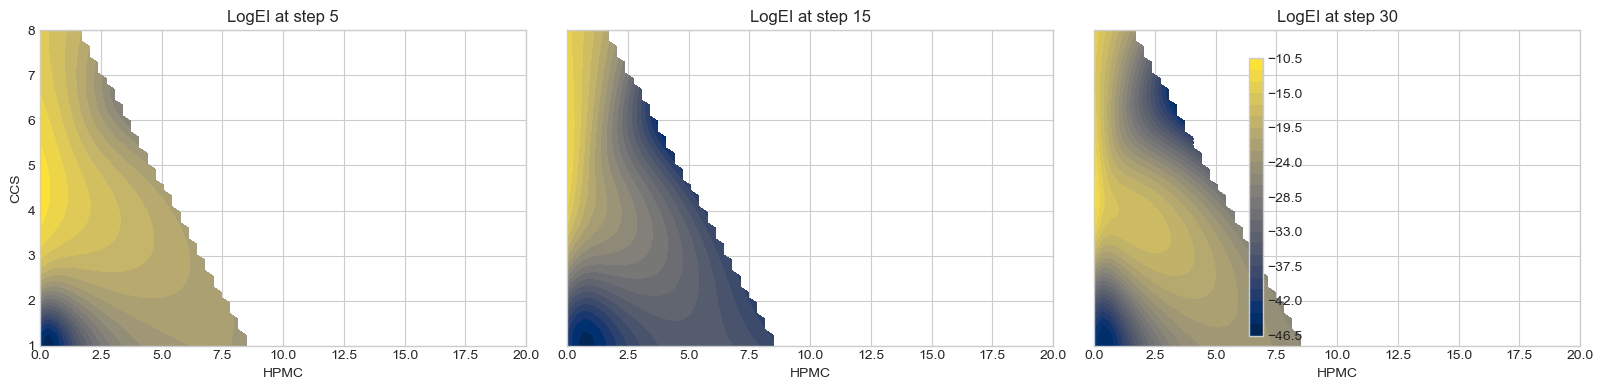

In [8]:
def snapshot_acq_landscape(seed, n_steps):
    loop = FormulationBOLoop(n_init=10, noise_std=2.0, seed=seed)
    loop.initialize()
    for _ in range(n_steps):
        loop.step()
    loop.fit_model()

    best_idx = int(torch.argmax(loop.Y).item())
    anchor = loop.X[best_idx].clone()
    acqf = LogExpectedImprovement(loop.model, best_f=loop.Y.max())

    H, C = torch.linspace(*BOUNDS["hpmc"], 60), torch.linspace(*BOUNDS["ccs"], 60)
    A = np.full((len(C), len(H)), np.nan)
    for i, c in enumerate(C):
        for j, h in enumerate(H):
            x = anchor.clone()
            x[0] = h
            x[2] = c
            if feasible_mask(x.unsqueeze(0)):
                A[i, j] = acqf(x.unsqueeze(0).unsqueeze(1)).item()
    return H.numpy(), C.numpy(), A

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True, sharey=True)
for ax, step in zip(axes, [5, 15, 30]):
    H, C, A = snapshot_acq_landscape(seed=123, n_steps=step)
    m = ax.contourf(H, C, A, levels=22, cmap="cividis")
    ax.set_title(f"LogEI at step {step}")
    ax.set_xlabel("HPMC")
axes[0].set_ylabel("CCS")
fig.colorbar(m, ax=axes.ravel().tolist(), shrink=0.9)
plt.tight_layout()
plt.show()

## Top 5 recommended formulations (posterior mean ± std)

In [9]:
bo.fit_model()
candidates = sample_feasible(1000, seed=314)
X4 = torch.tensor(candidates[["hpmc", "mcc", "ccs", "mgst"]].to_numpy(), dtype=torch.double)
post = bo.model.posterior(X4)
candidates["pred_mean"] = post.mean.detach().cpu().numpy().ravel()
candidates["pred_std"] = post.variance.sqrt().detach().cpu().numpy().ravel()
candidates["score"] = candidates["pred_mean"] + 0.5 * candidates["pred_std"]

cols = ["hpmc", "mcc", "ccs", "mgst", "pvp", "pred_mean", "pred_std"]
candidates.sort_values("score", ascending=False)[cols].head(5).round(3)

,hpmc,mcc,ccs,mgst,pvp,pred_mean,pred_std
103,0.167,58.599,6.137,0.286,4.810,97.227,0.828
206,0.489,55.412,6.365,0.648,7.086,96.460,0.693
891,1.340,56.692,6.811,0.355,4.803,96.387,0.755
193,0.618,58.518,7.721,0.502,2.641,96.328,0.842
770,2.367,49.935,7.470,0.346,9.881,96.252,0.816
